In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Initializing column names and loading the raw NASA CMAPSS Turbofan Engine Degradation dataset (FD001)
cols = ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + [f's{i}' for i in range(1, 22)]
df = pd.read_csv('../data/raw/train_FD001.csv', sep=r'\s+', header=None, names=cols)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (20631, 26)


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
# Calculating the total number of unique engine units and their maximum operational cycles
n_engines = df['unit_id'].nunique()
engine_lives = df.groupby('unit_id')['cycle'].max()

print(f"Total Number of Engines: {n_engines}")
print(f"Average Engine Lifespan: {engine_lives.mean():.1f} cycles")
print(f"Min / Max Lifespan: {engine_lives.min()} / {engine_lives.max()}")
engine_lives.describe()

Total Number of Engines: 100
Average Engine Lifespan: 206.3 cycles
Min / Max Lifespan: 128 / 362


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

In [3]:
# Plotting an interactive histogram to analyze the distribution of engine failure points
fig = px.histogram(engine_lives, nbins=30, title='Engine Lifetime Distribution',
                   labels={'value': 'Maximum Cycle', 'count': 'Frequency'},
                   color_discrete_sequence=['#e63946'])
fig.update_layout(template='plotly_dark')
fig.show()

In [4]:
# Calculating standard deviation for each sensor to filter out constant sensors with no degradation signal
sensor_cols = [f's{i}' for i in range(1, 22)]
sensor_std = df[sensor_cols].std()

print("Sensor Standard Deviation Values:")
print(sensor_std.sort_values())

# Dropping flat sensors (std < 0.5) that do not provide useful information for RUL prediction
flat_sensors = sensor_std[sensor_std < 0.5].index.tolist()
useful_sensors = sensor_std[sensor_std >= 0.5].index.tolist()

print(f"\nFlat Sensors (Dropped): {flat_sensors}")
print(f"Useful Sensors (Retained): {useful_sensors}")

Sensor Standard Deviation Values:
s1     0.000000e+00
s19    0.000000e+00
s18    0.000000e+00
s10    0.000000e+00
s16    3.469531e-18
s5     5.329200e-15
s6     1.388985e-03
s15    3.750504e-02
s8     7.098548e-02
s13    7.191892e-02
s21    1.082509e-01
s20    1.807464e-01
s11    2.670874e-01
s2     5.000533e-01
s12    7.375534e-01
s7     8.850923e-01
s17    1.548763e+00
s3     6.131150e+00
s4     9.000605e+00
s14    1.907618e+01
s9     2.208288e+01
dtype: float64

Flat Sensors (Dropped): ['s1', 's5', 's6', 's8', 's10', 's11', 's13', 's15', 's16', 's18', 's19', 's20', 's21']
Useful Sensors (Retained): ['s2', 's3', 's4', 's7', 's9', 's12', 's14', 's17']


In [5]:
# Visualizing degradation curves for a random sample of 5 engines to identify temporal patterns
sample_engines = np.random.choice(df['unit_id'].unique(), 5, replace=False)

fig = make_subplots(rows=3, cols=3, subplot_titles=useful_sensors[:9])
for idx, sensor in enumerate(useful_sensors[:9]):
    row, col = idx // 3 + 1, idx % 3 + 1
    for eng in sample_engines:
        sub = df[df['unit_id'] == eng]
        fig.add_trace(go.Scatter(x=sub['cycle'], y=sub[sensor],
                                  mode='lines', name=f'Engine {eng}',
                                  showlegend=(idx == 0)), row=row, col=col)

fig.update_layout(height=800, title_text='Sensor Degradation Curves (Sampled Units)', template='plotly_dark')
fig.show()

In [6]:
# Applying K-Means clustering to operational settings to identify different flight regimes
op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']
scaler = StandardScaler()
op_scaled = scaler.fit_transform(df[op_cols])

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['op_cluster'] = kmeans.fit_predict(op_scaled)

# Creating a 3D visualization of the identified operational clusters
fig = px.scatter_3d(df.sample(2000), x='op_setting_1', y='op_setting_2', z='op_setting_3',
                    color='op_cluster', title='Operational Condition Clusters',
                    color_continuous_scale='Viridis')
fig.update_layout(template='plotly_dark')
fig.show()

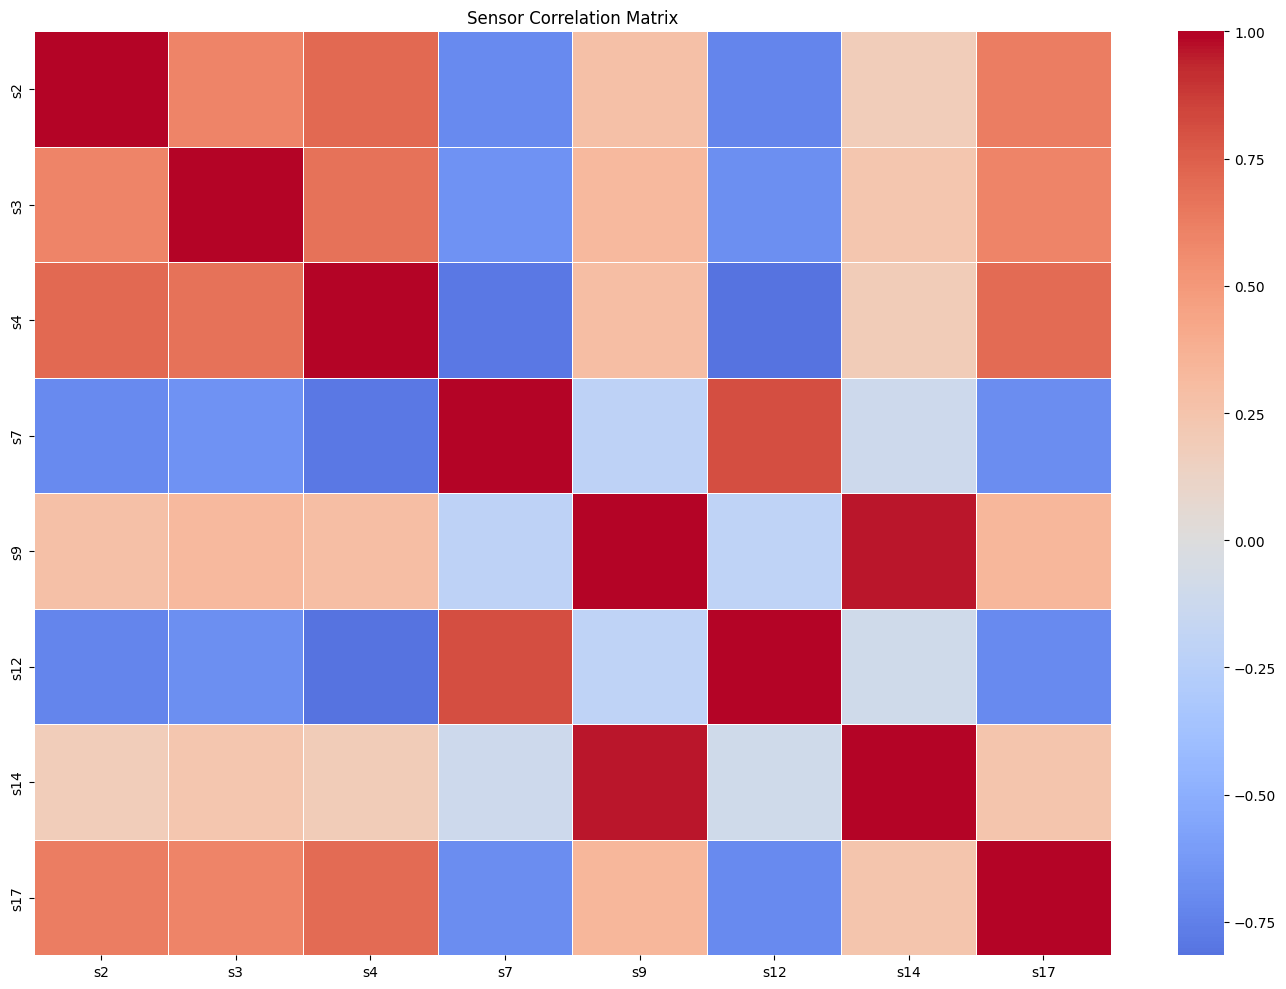

In [7]:
# Creating a heatmap to identify linear relationships and potential redundancy between useful sensors
plt.figure(figsize=(14, 10))
corr = df[useful_sensors].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.5)

plt.title('Sensor Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/sensor_correlation.png', dpi=150)
plt.show()

In [8]:
# Saving the cleaned dataset and the list of informative sensors to the processed data directory
df.to_csv('../data/processed/FD001_with_clusters.csv', index=False)
print('Informative sensors list exported:', useful_sensors)

import json
with open('../data/processed/useful_sensors.json', 'w') as f:
    json.dump(useful_sensors, f)

print('EDA step completed successfully. Data exported for Feature Engineering.')

Informative sensors list exported: ['s2', 's3', 's4', 's7', 's9', 's12', 's14', 's17']
EDA step completed successfully. Data exported for Feature Engineering.
